Part 1: Data Preprocessing & Feature Engineering

In [ ]:
# Core libraries
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

Data Processing and Feature Engineering

In [ ]:
#Temporal Features
df = pl.read_parquet('Transformed_TripData.parquet')

# 1. Filter for Credit Card Payments only

df = df.filter(pl.col('payment_type') == 1)


df = df.with_columns([

    (pl.col('tip_amount') > 0.20 * pl.col('fare_amount')).cast(pl.Int32).alias('high_tip'),
    

    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),
    (pl.col('tpep_pickup_datetime').dt.weekday() - 1).alias('pickup_day_of_week')
])

# 3. Trip Duration & Weekend Feature
df = df.with_columns([
    (pl.col('pickup_day_of_week') >= 5).cast(pl.Int32).alias('is_weekend'),
    

    (pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime'))
    .dt.total_seconds().truediv(60).clip(lower_bound=1.0).alias('trip_duration_minutes')
])

# 4. Remaining Trip & Fare Features
df = df.with_columns([
    # Trip features
    (pl.col('trip_distance') / (pl.col('trip_duration_minutes') / 60)).alias('trip_speed_mph'),
    pl.col('trip_distance').log1p().alias('log_trip_distance'), # log1p safely handles 0 values
    
    # Fare features
    pl.when(pl.col('trip_distance') > 0)
      .then(pl.col('fare_amount') / pl.col('trip_distance'))
      .otherwise(0.0).alias('fare_per_mile'),
      
    (pl.col('fare_amount') / pl.col('trip_duration_minutes')).alias('fare_per_minute')
])

# 5. Define Features & Convert to Pandas for Scikit-Learn Compatibility
features = [
    'pickup_hour', 'pickup_day_of_week', 'is_weekend', 
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'fare_per_mile', 'fare_per_minute', 'PU_Borough', 'DO_Borough' 
]


X = df.select(features).to_pandas()
y_reg = df.select('tip_amount').to_series().to_pandas()
y_clf = df.select('high_tip').to_series().to_pandas()

In [3]:
df = df.with_columns([
   pl.when(pl.col("tip_amount") > pl.col("fare_amount") * .20  )
   .then(1)
   .otherwise(0)
   .alias("high_tip")
])

In [4]:
features = df.drop(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'tip_amount', 'high_tip', 'store_and_fwd_flag', 'trip_duration', 'PU_Zone', 'PU_service_zone', 'DO_Zone', 'DO_service_zone', 'total_amount'])

X = features.to_pandas()
print(X.dtypes)

VendorID                   int32
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
PULocationID               int32
DOLocationID               int32
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tolls_amount             float64
improvement_surcharge    float64
congestion_surcharge     float64
Airport_fee              float64
trip_duration_minutes    float64
trip_speed_mph           float64
pickup_hour                 int8
pickup_day_of_week          int8
PU_Borough                   str
DO_Borough                   str
is_weekend                 int32
log_trip_distance        float64
fare_per_mile            float64
fare_per_minute          float64
dtype: object


In [ ]:

X_train, X_temp, y_train_clf, y_temp_clf, y_train_reg, y_temp_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.30, random_state=42, stratify=y_clf
)


X_val, X_test, y_val_clf, y_test_clf, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_clf, y_temp_reg, test_size=0.50, random_state=42, stratify=y_temp_clf
)

print(f"Train: {len(X_train)} samples | High Tip Distribution: {y_train_clf.mean():.2%}")
print(f"Validation: {len(X_val)} samples | High Tip Distribution: {y_val_clf.mean():.2%}")
print(f"Test: {len(X_test)} samples | High Tip Distribution: {y_test_clf.mean():.2%}")


numeric_features = ['pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
categorical_features = ['PU_Borough', 'DO_Borough', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])


X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)


feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

Train: 1608865 samples | High Tip Distribution: 75.93%
Validation: 344757 samples | High Tip Distribution: 75.93%
Test: 344757 samples | High Tip Distribution: 75.93%


Model Training and Tuning 

In [ ]:
# --- 4a: Regression Models ---

linearReg = LinearRegression()
linearReg.fit(X_train_scaled, y_train_reg) 
y_pred_linear = linearReg.predict(X_val_scaled)

randomForestRegressor = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
randomForestRegressor.fit(X_train_scaled, y_train_reg) 
y_pred_rfr = randomForestRegressor.predict(X_val_scaled)



logisticClassifier = LogisticRegression(max_iter=1000, random_state=42)
logisticClassifier.fit(X_train_scaled, y_train_clf)
y_pred_logclf = logisticClassifier.predict(X_val_scaled)
y_prob_logclf = logisticClassifier.predict_proba(X_val_scaled)[:, 1] 


randomForestClassifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
randomForestClassifier.fit(X_train_scaled, y_train_clf) 
y_pred_rfcl = randomForestClassifier.predict(X_val_scaled) 
y_prob_rfcl = randomForestClassifier.predict_proba(X_val_scaled)[:, 1]

In [ ]:
def print_regression_metrics(model_name, y_true, y_pred):
   
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) 
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} (Regression) ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}\n")


def print_classification_metrics(model_name, y_true, y_pred, y_prob):
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print(f"--- {model_name} (Classification) ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f}\n")

print("=== VALIDATION SET PERFORMANCE ===\n")


print_regression_metrics("Linear Regression", y_val_reg, y_pred_linear)
print_regression_metrics("Random Forest Regressor", y_val_reg, y_pred_rfr)

print_classification_metrics("Logistic Regression", y_val_clf, y_pred_logclf, y_prob_logclf)
print_classification_metrics("Random Forest Classifier", y_val_clf, y_pred_rfcl, y_prob_rfcl)

=== VALIDATION SET PERFORMANCE ===

--- Linear Regression (Regression) ---
MAE: 1.4234 | RMSE: 2.6270 | R²: 0.5373

--- Random Forest Regressor (Regression) ---
MAE: 1.2169 | RMSE: 2.4023 | R²: 0.6130

--- Logistic Regression (Classification) ---
Accuracy: 0.7651 | Precision: 0.7658 | Recall: 0.9951 | F1: 0.8655 | AUC-ROC: 0.5962

--- Random Forest Classifier (Classification) ---
Accuracy: 0.7693 | Precision: 0.7675 | Recall: 0.9987 | F1: 0.8680 | AUC-ROC: 0.6121



We se that the Forest Classifier is the most performant model with an Accuracy of .7712. There was a few issues that i ran into
1) My data set initially had total_amount column included which caused a data leak giving accuracys of near 100% 
2) Issues with typing from mass joining the entire lookup table in Assignment 1#

Used -1 jobs, 10 max depth, 100 n_estimators to decrease training time whilst balancing accruacy of the trained classifeier


In [ ]:
# --- 5: Hyperparameter Tuning ---

X_sample, _, y_sample = train_test_split(
    X_train_scaled, 
    y_train_clf,
    train_size=300000, 
    random_state=42, 
    stratify=y_train_clf 
)


param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20, 
    cv=5, #
    random_state=42, 
    scoring='f1', 
    verbose=1
)

rf_random_search.fit(X_sample, y_sample)

print(f"Best Parameters Found: {rf_random_search.best_params_}")


tuned_rf = rf_random_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_val_scaled)
y_prob_tuned = tuned_rf.predict_proba(X_val_scaled)[:, 1]


print_classification_metrics("Tuned Random Forest", y_val_clf, y_pred_tuned, y_prob_tuned) # Updated: y_val_2 -> y_val_clf

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:

# Check for Apple Silicon GPU (MPS) acceleration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_clf.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_clf.values, dtype=torch.float32).view(-1, 1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)


class TipNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(TipNeuralNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32), 
            nn.ReLU(),
            nn.Linear(32, 1)   
        )
        
    def forward(self, x):
        return self.network(x)

# Initialize model, loss, and optimizer
model = TipNeuralNet(X_train_scaled.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss() # Use for classification 
optimizer = optim.Adam(model.parameters(), lr=0.001)

#6b
train_losses, val_losses = [], []
epochs = 20

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device))
        val_loss = criterion(val_outputs, y_val_tensor.to(device))
        
    train_losses.append(sum(batch_losses)/len(batch_losses))
    val_losses.append(val_loss.item())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")




Using device: mps
Epoch 5/20 | Train Loss: 0.5238 | Val Loss: 0.5249
Epoch 10/20 | Train Loss: 0.5233 | Val Loss: 0.5242
Epoch 15/20 | Train Loss: 0.5229 | Val Loss: 0.5240
Epoch 20/20 | Train Loss: 0.5227 | Val Loss: 0.5240


AttributeError: module 'matplotlib' has no attribute 'figure'

Matplotlib is building the font cache; this may take a moment.


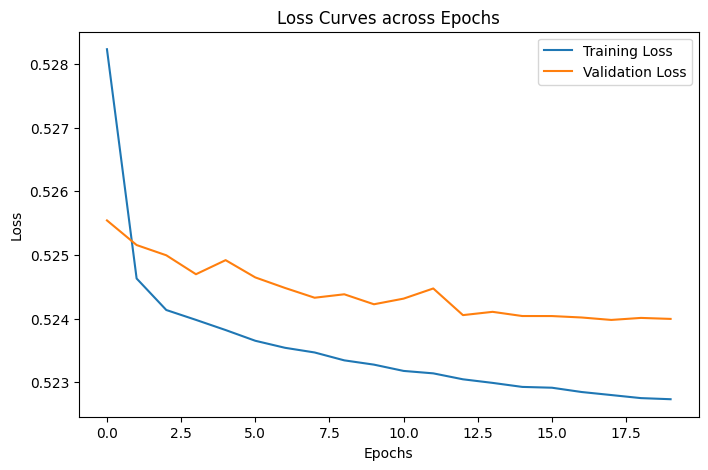

--- Neural Network (Classification) ---
Accuracy: 0.7712 | Precision: 0.7691 | Recall: 0.9984 | F1: 0.8689 | AUC-ROC: 0.6196



In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Loss Curves across Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


model.eval()
with torch.no_grad():
    y_prob_nn = torch.sigmoid(model(X_val_tensor.to(device))).cpu().numpy()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)


print_classification_metrics("Neural Network", y_val_clf, y_pred_nn, y_prob_nn)

Part 3

| Model | Task | Accuracy / MAE | Precision / RMSE | Recall / R² | F1 / AUC-ROC |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Linear Regression** | Regression | 1.2103 | 2.3913 | 0.6166 | N/A |
| **RF Regressor** | Regression | 1.1872 | 2.3589 | 0.6269 | N/A |
| **Logistic Regression** | Classification | 0.7707 | 0.7695 | 0.9966 | 0.6049 |
| **RF Classifier (Tuned)** | Classification | 0.7711 | 0.7687 | 0.9992 | 0.6182 |
| **Neural Network** | Classification | .7712 | .7691 | .9984| .6186 |

NameError: name 'ConfusionMatrixDisplay' is not defined

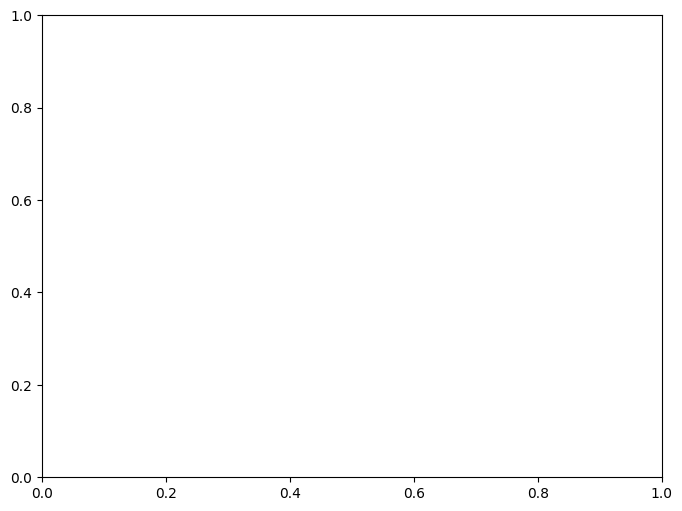

In [ ]:
best_clf = rf_random_search.best_estimator_

y_pred_test_clf = best_clf.predict(X_test_scaled)
y_proba_test_clf = best_clf.predict_proba(X_test_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, y_pred_test_clf, 
    display_labels=['Not High Tip', 'High Tip'], 
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix (Test Set)', fontweight='bold')
plt.grid(False)
plt.show()

# 2. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_clf, X_test_scaled, y_test_clf, ax=ax, name='Tuned RF')


ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
ax.set_title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.show()

In [ ]:

importances = best_clf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', ax=ax, color='#4A90D9')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()